# Massive Problem

Solution author: Walnit

# Dataset

In [1]:
! kaggle competitions download -c massive-problem-aicc-round-6
! 7z x massive-problem-aicc-round-6.zip

100% 148M/148M [00:04<00:00, 34.5MB/s]


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.00GHz (50653),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan         1 file, 155497206 bytes (149 MiB)

Extracting archive: massive-problem-aicc-round-6.zip
--
Path = massive-problem-aicc-round-6.zip
Type = zip
Physical Size = 155497206

  0%      1% 1 - massive-problem-aicc-round-X/task_data/RNA_seq_patient_0.csv                                                                       3% 1 - massive-problem-aicc-round-X/task_data/RNA_seq_patient_0.csv                                                                     

In [2]:
! mv massive-problem-aicc-round-X/task_data .

# Solution

This task may seem impossible and unfair. Every solution you can think of just seems to fall short of your expectations - and may even do worse than baseline.  

That's because this task is based on an active area of research - Genomics. In the world of biology, there are just so many cells, so many genes, so many sources of interference.  

Let's start by visualizing the data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

In [2]:
dtypes = {
    f"Gene{n}": "uint16" for n in range(1, 1435)
}
dtypes["batch"] = "int8"

In [3]:
dfs = []
for p in range(0, 9):
    dfs.append(pd.read_csv(f"task_data/RNA_seq_patient_{p}.csv", dtype=dtypes))
df = pd.concat(dfs, ignore_index=True)
df.drop("Unnamed: 0", axis=1, inplace=True)

test_df = pd.read_csv("task_data/test.csv", dtype=dtypes)
test_df.drop("Unnamed: 0", axis=1, inplace=True)

In [4]:
for d in dfs:
    del d
del dfs

We use a UMAP to visualize the distribution of the data.

In [ ]:
!pip install umap-learn

In [ ]:
import umap

reducer = umap.UMAP()
embedding = reducer.fit_transform(df.iloc[:, :1434])
embedding.shape

(261390, 2)

From the UMAP visualization, it seems that the label is definitely not causing a majority of the variation in values.

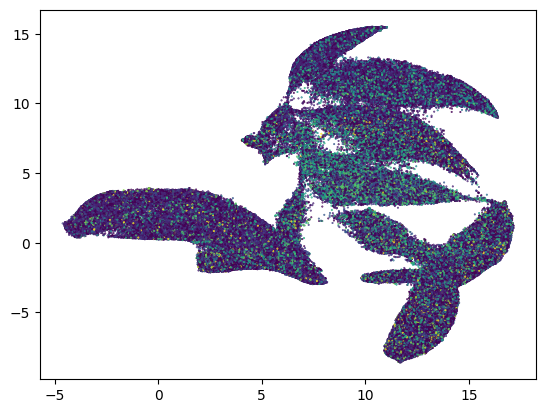

In [ ]:
plt.scatter(embedding[:, 0], embedding[:, 1], s=0.2, c=df["label"])

Rather, it is the batch of data collection. The main task at hand is thus **batch correction**, or reducing the influence of the batch on the data.

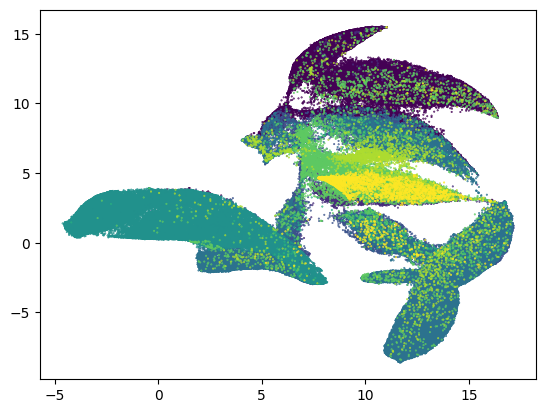

In [ ]:
plt.scatter(embedding[:, 0], embedding[:, 1], s=0.2, c=df["batch"])

In [ ]:
del reducer, embedding

In [ ]:
df_genes = df.iloc[:, :1434]
df_label = df.iloc[:, 1434]
df_batch = df.iloc[:, 1435]

## Approach 1: *"☝️🤓 Erm, actually..."*  

*...(sniffs) there are software libraries made precisely to tackle this foundational problem of batch correction!! I've done (adjusts glasses) active research in the field of Genomics... erm... and the best way to approach this problem is... uh...*

🤓🤓🤓 NERDDDDDDD.  

But in the off chance you have had prior exposure to this field, some tools may come to mind. In this approach, we use **scANVI (single-cell ANnotation using Variational Inference)**, a semi-supervised technique specifically designed for *single-cell transcriptomics data*. Whatever that means.  

We start by installing the required package.

In [ ]:
!pip install scvi-colab
from scvi_colab import install
install()

INFO     scvi-colab: Installing scvi-tools.                                                                        
INFO     scvi-colab: Install successful. Testing import.                                                           


/usr/local/lib/python3.12/dist-packages/pyro/ops/stats.py:527: SyntaxWarning: invalid escape sequence '\g'
  we have :math:`ES^{*}(P,Q) \ge ES^{*}(Q,Q)` with equality holding if and only if :math:`P=Q`, i.e.


In [ ]:
import scanpy as sc
import scvi

We package the data in the format the library expects...

In [ ]:
df_genes_combined = pd.concat([df_genes, test_df.iloc[:, :1434]])
df_label_combined = pd.concat([df_label, pd.Series(np.full(test_df.shape[0], -1))])
df_batch_combined = pd.concat([df_batch, test_df.iloc[:, 1434]])

In [ ]:
adata = sc.AnnData(X=df_genes_combined.values)
adata.obs["batch"] = df_batch_combined.values
adata.obs["cell_type"] = df_label_combined.values

adata.layers["counts"] = adata.X.copy()

In [ ]:
sc.pp.highly_variable_genes(
    adata,
    flavor="seurat_v3",
    n_top_genes=500,
    layer="counts",
    batch_key="batch",
    subset=True
)

Train scVI, an unsupervised version of scANVI, as initialization for scANVI...

In [ ]:
gscvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="batch")
vae = scvi.model.SCVI(adata, n_latent=30, n_layers=2)
vae.train()

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespe

Training:   0%|          | 0/30 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=30` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


Then we train scANVI...

In [ ]:
adata.obs["cell_type"] = adata.obs["cell_type"].astype(str)

scvi.model.SCANVI.setup_anndata(
    adata,
    layer="counts",
    batch_key="batch",
    labels_key="cell_type",
    unlabeled_category="-1.0"
)

In [ ]:
scanvi = scvi.model.SCANVI.from_scvi_model(
    vae,
    adata=adata,
    unlabeled_category="-1.0",
    labels_key="cell_type",
)

scanvi.train(max_epochs=20)

INFO     Training for 20 epochs.                                                                                   


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespe

Training:   0%|          | 0/20 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=20` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


...and we're done! Let's call the prediction function and grab the embeddings while we're at it.

In [ ]:
adata.obsm["X_scVI"] = scanvi.get_latent_representation()
adata.obs["pred_label"] = scanvi.predict()

Now, we visualize the embeddings to see how it has changed.

In [ ]:
import umap

reducer = umap.UMAP()
embedding = reducer.fit_transform(adata.obsm["X_scVI"])
embedding.shape

(268791, 2)

From this, you can see that the batch is no longer the main factor in determining the clusters in the visualization.

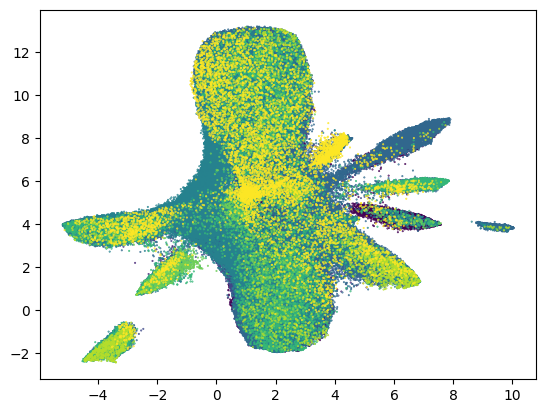

In [ ]:
plt.scatter(embedding[:, 0], embedding[:, 1], s=0.2, c=adata.obs["batch"])

Rather, the clusters much more closely represent the labelled cell types. Success!

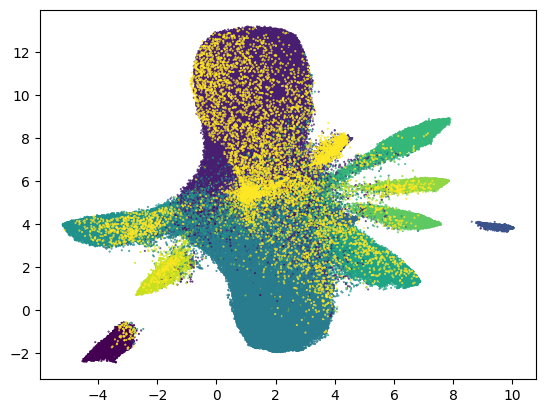

In [ ]:
plt.scatter(embedding[:, 0], embedding[:, 1], s=0.2, c=adata.obs["_scvi_labels"])

This approach scores **0.3922** on the public set, and **0.3811** on the private set.  

However, it's not possible to know the "correct", field-specific approach for *every* problem out there. In those cases, how would we approach this problem?

# Approach 2: Standard Approach

The very first thing to prepare, for every task, is a good validation set. Selecting the validation set by random sampling is a horrible idea, due to the strong effect of the batch on the data.  

Rather, similar to the test set being its own batch, we will choose one batch to be the validation set. We choose Batch 1 as it has a similar number of rows to the test set.

In [5]:
test_df.shape[0], df["batch"].value_counts()

(7401,
 batch
 3    102135
 4     59796
 0     51548
 2     16716
 6     16043
 1      7291
 8      3543
 7      3306
 5      1012
 Name: count, dtype: int64)

In [6]:
val_df = df[df["batch"]==1]
train_df = df[df["batch"]!=1]

Let's also look into the values of the data. You can see that the expression values of each gene are heavily right-skewed.

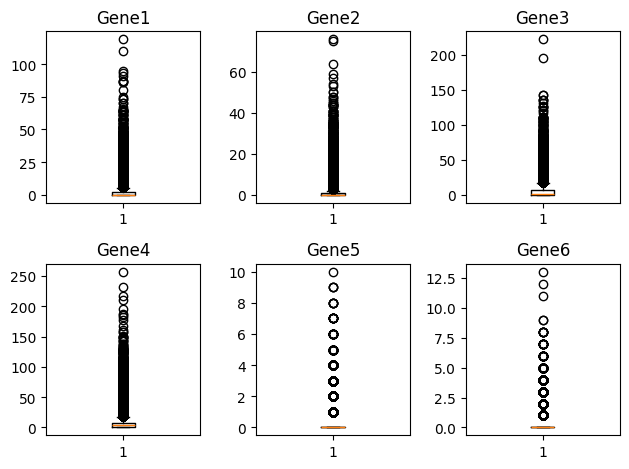

In [7]:
fig, axes = plt.subplots(2, 3)

axes = axes.flatten()

for i in range(6):
    axes[i].boxplot(train_df.iloc[:, i])
    axes[i].set_title(f'{train_df.columns[i]}')

plt.tight_layout()
plt.show()

We can try to mitigate this by converting it to a log-scale.

In [8]:
log_train_df_genes = np.log(train_df.iloc[:, :1434] + 1) # add 1 so we don't log 0|

Now the distribution looks just a bit better!

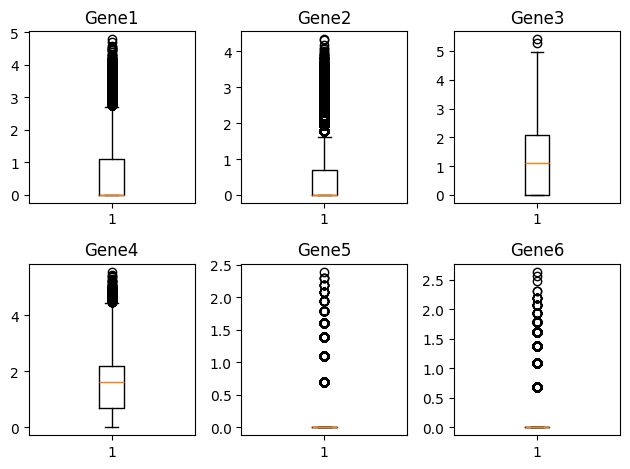

In [9]:
fig, axes = plt.subplots(2, 3)

axes = axes.flatten()

for i in range(6):
    axes[i].boxplot(log_train_df_genes.iloc[:, i])
    axes[i].set_title(f'{log_train_df_genes.columns[i]}')

plt.tight_layout()
plt.show()

Let's plot the mean and standard deviation of the genes overall as a sanity check. Nothing stands out too much, so we shouldn't need to bother this.

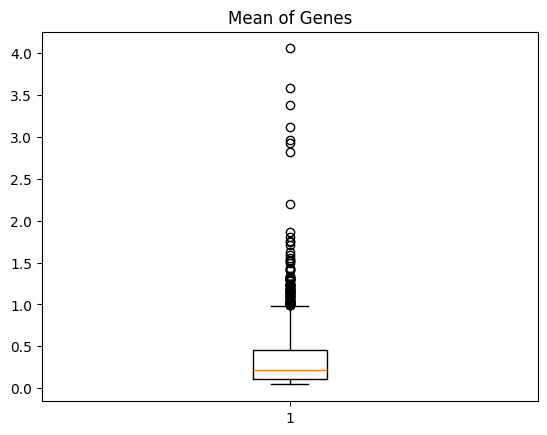

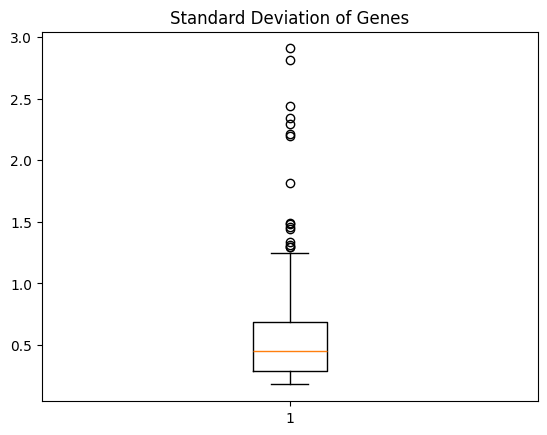

In [10]:
plt.boxplot(log_train_df_genes.mean(axis=0))
plt.title("Mean of Genes")
plt.show()

plt.boxplot(log_train_df_genes.std(axis=0))
plt.title("Standard Deviation of Genes")
plt.show()

With major fundamnetal issues with the dataset out of the way, let's try running an ML model on the data.  

Let's use CatBoost because it's fast and good with high-cardinality data.

In [11]:
! pip install catboost --quiet

Remember to use the GPU to make things faster!

In [12]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    task_type="GPU",
    use_best_model=True,
    early_stopping_rounds=50
)

model.fit(
    log_train_df_genes,
    train_df["label"],
    eval_set=(np.log(val_df.iloc[:, :1434]+1), val_df["label"]),
    verbose=50
)

Learning rate set to 0.183966
0:	learn: 1.9267942	test: 2.0962559	best: 2.0962559 (0)	total: 582ms	remaining: 9m 41s
50:	learn: 0.8548439	test: 1.2611009	best: 1.2611009 (50)	total: 10.2s	remaining: 3m 10s
100:	learn: 0.6989303	test: 1.1032722	best: 1.1032722 (100)	total: 17.8s	remaining: 2m 38s
150:	learn: 0.6170714	test: 1.0368149	best: 1.0368149 (150)	total: 26.7s	remaining: 2m 30s
200:	learn: 0.5640567	test: 0.9711721	best: 0.9704079 (196)	total: 32.3s	remaining: 2m 8s
250:	learn: 0.5301953	test: 0.9546591	best: 0.9536802 (249)	total: 38.6s	remaining: 1m 55s
300:	learn: 0.5078437	test: 0.9334132	best: 0.9320426 (298)	total: 43.6s	remaining: 1m 41s
350:	learn: 0.4912785	test: 0.9237332	best: 0.9237332 (350)	total: 48.3s	remaining: 1m 29s
400:	learn: 0.4802386	test: 0.9111078	best: 0.9111078 (400)	total: 53.7s	remaining: 1m 20s
450:	learn: 0.4714573	test: 0.9096270	best: 0.9076715 (447)	total: 58.1s	remaining: 1m 10s
500:	learn: 0.4645594	test: 0.9072370	best: 0.9044706 (478)	total: 

CatBoostClassifier(early_stopping_rounds=50, task_type='GPU', use_best_model=True)

As an aside, let's see how well the model does on our validation set.

In [13]:
f1_score(model.predict(np.log(val_df.iloc[:, :1434]+1)), val_df["label"], average="macro")

0.43126764233499826

Not too bad! This alone actually gets you to **0.3818** and **0.4061** on the private and public leaderboards respectively.

## Further Analysis

One way to reduce the size of our dataset is by reducing the number of features via filtering by feature importance. It seems that many features have low importance, according to CatBoost.

{'whiskers': [<matplotlib.lines.Line2D at 0x7df642846930>,
 'caps': [<matplotlib.lines.Line2D at 0x7df6428471a0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7df64281cc20>],
 'medians': [<matplotlib.lines.Line2D at 0x7df6428479e0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7df642847e30>],
 'means': []}

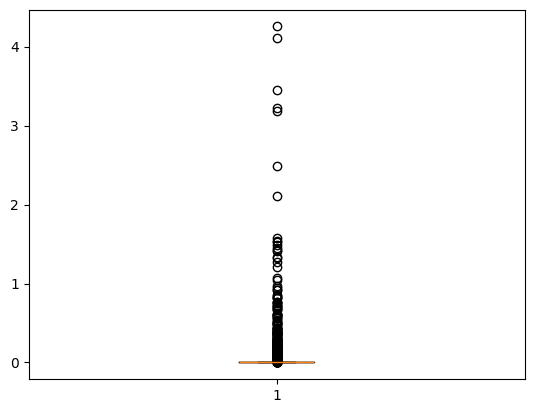

In [14]:
plt.boxplot(model.feature_importances_)

In fact, even the median has a feature importance of zero!

In [15]:
np.quantile(model.feature_importances_, 0.5)

np.float64(0.0)

Let's just pick the non-zero genes and keep them.

In [16]:
important_genes = np.where(model.feature_importances_ != 0)[0]
log_train_df_genes_filtered = log_train_df_genes.iloc[:, important_genes]
log_train_df_genes_filtered

,Gene1,Gene3,Gene4,Gene6,Gene7,Gene10,Gene11,Gene12,Gene13,Gene17,...,Gene1416,Gene1417,Gene1418,Gene1421,Gene1422,Gene1424,Gene1425,Gene1428,Gene1432,Gene1433
0,0.000000,0.693147,1.609438,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.098612,0.693147,1.098612,0.0,0.000000,0.0,0.000000,0.693147
1,0.000000,0.000000,0.000000,0.000000,0.693147,0.0,0.0,0.693147,0.000000,0.000000,...,0.693147,0.693147,0.000000,0.000000,0.000000,0.0,0.693147,0.0,0.000000,0.693147
2,1.945910,0.693147,1.791759,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
3,0.000000,0.000000,2.564949,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.693147,1.609438,1.386294,0.0,0.000000,0.0,0.693147,0.693147
4,0.000000,0.000000,2.944439,0.693147,0.000000,0.0,0.0,0.693147,0.693147,0.693147,...,0.693147,0.000000,0.693147,0.693147,2.564949,0.0,0.000000,0.0,0.693147,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261385,1.098612,0.000000,1.098612,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
261386,1.098612,0.000000,2.302585,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.693147,0.000000,0.0,0.000000,0.0,0.000000,0.000000
261387,1.098612,1.098612,1.609438,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000
261388,1.609438,0.000000,1.945910,0.000000,0.000000,0.0,0.0,1.386294,0.000000,0.000000,...,0.000000,0.693147,0.000000,0.693147,2.079442,0.0,0.000000,0.0,0.000000,0.000000


Now, let's visualize the data that we have.

In [ ]:
import umap

reducer = umap.UMAP()
embedding = reducer.fit_transform(log_train_df_genes_filtered)
embedding.shape

(254099, 2)

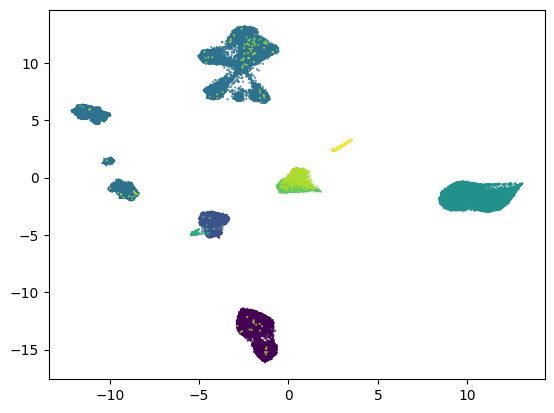

In [ ]:
plt.scatter(embedding[:, 0], embedding[:, 1], s=0.2, c=train_df["batch"])

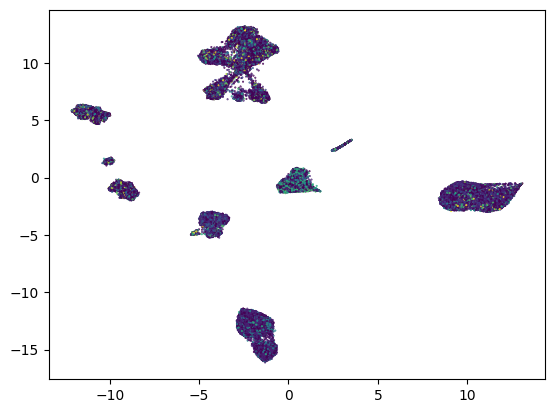

In [ ]:
plt.scatter(embedding[:, 0], embedding[:, 1], s=0.2, c=train_df["label"])

In [ ]:
del embedding

After all this, the batch still has a huge effect on the data. How can we mitigate this?  

The approach taken below is based partly on **ComBat (Combatting Batch Effects)**, a technique used in... genomics. *(sigh)*  

We're not going to just import a random library though! We're just going to borrow a simple idea: shifting the means of each batch such that they align, instead of being distinctly separate like the one above.  

To start, we need to get the overall mean of the entire dataset. We should include our validation and test sets, as ComBat is an unsupervised technique.

In [17]:
log_df_filtered = pd.concat((
    log_train_df_genes_filtered,
    np.log(val_df.iloc[:, important_genes]+1),
    np.log(test_df.iloc[:, important_genes]+1)
))

In [18]:
df_batch = np.concat((train_df["batch"], val_df["batch"], test_df["batch"]))

Let's calculate the overall mean.

In [19]:
overall_mean = log_df_filtered.mean(axis=0)

Now, we will go through each of the batches, and correct the mean and standard deviation within each batch to match that of the overall.

In [20]:
log_df_corrected = np.copy(log_df_filtered)

for b in np.unique(df_batch):
    batch_idx = (df_batch == b)
    batch = log_df_filtered[batch_idx]

    # Obtain batch-specific distribution
    batch_mean = batch.mean(axis=0)

    # Correct the distribution
    corrected_batch = (batch - batch_mean) + overall_mean

    log_df_corrected[batch_idx] = corrected_batch

With that done, let's find our train set and visualize it again to see what changed.

In [21]:
log_train_df_corrected = log_df_corrected[(df_batch!=1) & (df_batch!=9)]

In [23]:
import umap

reducer = umap.UMAP()
embedding = reducer.fit_transform(log_train_df_corrected)
embedding.shape

(254099, 2)

Now the clusters look more merged-together.

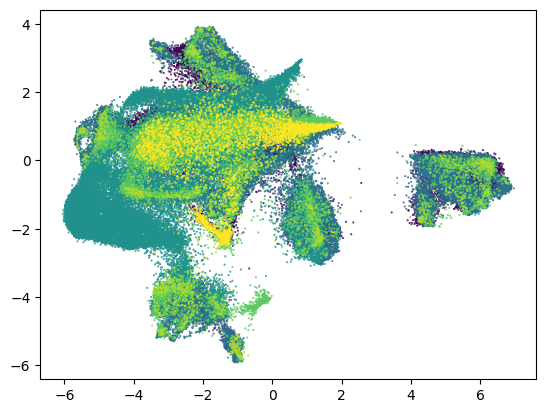

In [24]:
plt.scatter(embedding[:, 0], embedding[:, 1], s=0.2, c=train_df["batch"])

However, the labels do not cluster cleanly.

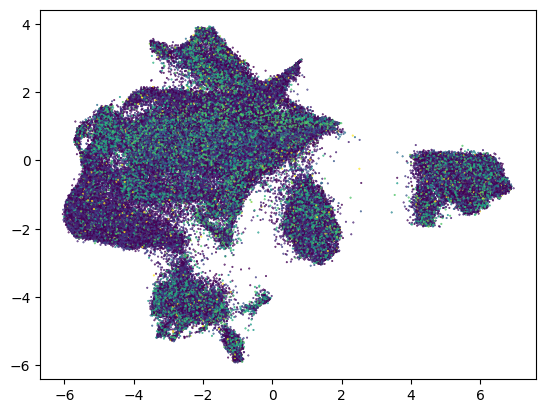

In [25]:
plt.scatter(embedding[:, 0], embedding[:, 1], s=0.2, c=train_df["label"])

Let's throw the data back at CatBoost and see how it fares.

In [26]:
from catboost import CatBoostClassifier

model = CatBoostClassifier(
    task_type="GPU",
    use_best_model=True,
    early_stopping_rounds=50
)

model.fit(
    log_train_df_corrected,
    train_df["label"],
    eval_set=(log_df_corrected[df_batch==1], val_df["label"]),
    verbose=50
)

Learning rate set to 0.183966
0:	learn: 1.9159626	test: 2.0817422	best: 2.0817422 (0)	total: 160ms	remaining: 2m 39s
50:	learn: 0.8365570	test: 1.2688644	best: 1.2688644 (50)	total: 4.1s	remaining: 1m 16s
100:	learn: 0.6793115	test: 1.1109901	best: 1.1109901 (100)	total: 9.37s	remaining: 1m 23s
150:	learn: 0.6013945	test: 1.0388388	best: 1.0388388 (150)	total: 13.5s	remaining: 1m 15s
200:	learn: 0.5522383	test: 1.0143713	best: 1.0140677 (198)	total: 17.6s	remaining: 1m 9s
250:	learn: 0.5183766	test: 0.9901891	best: 0.9901891 (250)	total: 23.8s	remaining: 1m 10s
300:	learn: 0.4943565	test: 0.9766804	best: 0.9737201 (286)	total: 27.9s	remaining: 1m 4s
350:	learn: 0.4777629	test: 0.9687707	best: 0.9677479 (346)	total: 31.6s	remaining: 58.5s
400:	learn: 0.4638202	test: 0.9647847	best: 0.9644957 (399)	total: 35.8s	remaining: 53.5s
450:	learn: 0.4529512	test: 0.9555932	best: 0.9553803 (449)	total: 39.8s	remaining: 48.5s
500:	learn: 0.4453866	test: 0.9534866	best: 0.9534866 (500)	total: 43s	r

CatBoostClassifier(early_stopping_rounds=50, task_type='GPU', use_best_model=True)

The score seems lower here. However, when used on the test set, we get a score of **0.3774** (lower...) and **0.4285** (higher!) on private and public leaderboards.  

In [27]:
f1_score(model.predict(log_df_corrected[df_batch==1]), val_df["label"], average="macro")

0.4030581278499641

We'll likely get much better results if we use ComBat proper, or run scANVI on it. But we'll leave that as an exercise for you. 😄